# Assignment 8: Pre-trained BERT for Sentiment Analysis

## Objective

Implement a pre-trained BERT (Bidirectional Encoder Representations from Transformers) model for sentiment analysis on a text classification dataset. The assignment demonstrates how a pre-trained Transformer-based language model can be fine-tuned for a downstream classification task.

## Dataset

The **Stanford Sentiment Treebank (SST-2)** dataset is used for binary sentiment classification. Each sample contains a sentence labeled as either **Positive (1)** or **Negative (0)**.

## Model

A pre-trained **BERT Base Uncased (`bert-base-uncased`)** model is used and fine-tuned on the SST-2 dataset.

## Methodology

The assignment follows these steps:

1. Load and explore the SST-2 dataset.
2. Analyze the class distribution and text characteristics.
3. Preprocess the text using the BERT tokenizer.
4. Prepare the training, validation, and test datasets.
5. Load the pre-trained BERT model with a classification head.
6. Fine-tune BERT on the sentiment classification task.
7. Evaluate the model using accuracy, precision, recall, and F1-score.
8. Visualize the training performance and confusion matrix.
9. Perform sentiment predictions on sample text inputs.
10. Analyze the results and summarize the performance of the fine-tuned BERT model.

## Reproducibility

A fixed random seed of **42** is used wherever applicable to ensure reproducibility of the experiments.


## 1. Import Libraries and Configuration

The required libraries are imported for dataset loading, data manipulation, visualization, BERT-based text classification, model training, and evaluation.

A fixed random seed of **42** is used to improve reproducibility. The available computation device is detected automatically, allowing the model to use the CUDA-enabled GPU when available.

In [1]:
# Standard libraries
import os
import random

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch

# Hugging Face
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed
)

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {__import__('transformers').__version__}")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"GPU Memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.2f} GB"
    )

PyTorch version: 2.13.0+cu130
Transformers version: 5.17.0
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU Memory: 6.00 GB


## 2. Load the SST-2 Dataset

The **Stanford Sentiment Treebank (SST-2)** dataset is used for binary sentiment classification.

Each example contains a sentence and a sentiment label:

* **0 → Negative**
* **1 → Positive**

The dataset provides separate training, validation, and test splits. We will first load the dataset and inspect its structure, number of samples, and available features.

In [2]:
# Load the SST-2 dataset
dataset = load_dataset("nyu-mll/glue", "sst2")

# Display dataset structure
dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [3]:
# Display the features
print("\nFeatures:")
print(dataset["train"].features)


Features:
{'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive']), 'idx': Value('int32')}


In [4]:
# Display the number of samples in each split
print("\nDataset sizes:")
for split in dataset:
    print(f"{split.capitalize():10}: {len(dataset[split])}")


Dataset sizes:
Train     : 67349
Validation: 872
Test      : 1821


## 3. Dataset Inspection

Before preprocessing the text, we inspect representative samples from the training set.

This helps us understand the structure of the dataset, verify the sentiment labels, and observe how the raw sentences are represented before they are passed to the BERT tokenizer.

In [5]:
# Display sample records from the training set
train_samples = dataset["train"].select(range(5))

for i, sample in enumerate(train_samples):
    print(f"Sample {i + 1}")
    print(f"Sentence: {sample['sentence']}")
    print(f"Label: {sample['label']} ({dataset['train'].features['label'].names[sample['label']]})")
    print(f"Index: {sample['idx']}")
    print("-" * 80)

Sample 1
Sentence: hide new secretions from the parental units 
Label: 0 (negative)
Index: 0
--------------------------------------------------------------------------------
Sample 2
Sentence: contains no wit , only labored gags 
Label: 0 (negative)
Index: 1
--------------------------------------------------------------------------------
Sample 3
Sentence: that loves its characters and communicates something rather beautiful about human nature 
Label: 1 (positive)
Index: 2
--------------------------------------------------------------------------------
Sample 4
Sentence: remains utterly satisfied to remain the same throughout 
Label: 0 (negative)
Index: 3
--------------------------------------------------------------------------------
Sample 5
Sentence: on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
Label: 0 (negative)
Index: 4
--------------------------------------------------------------------------------


## 4. Class Distribution

Class distribution is examined to determine whether the sentiment classes are reasonably balanced.

A balanced dataset helps ensure that the model does not become biased toward one sentiment class. We will calculate the number and percentage of positive and negative samples in the training set and visualize the distribution.

  Sentiment  Count  Percentage
0  negative  29780       44.22
1  positive  37569       55.78


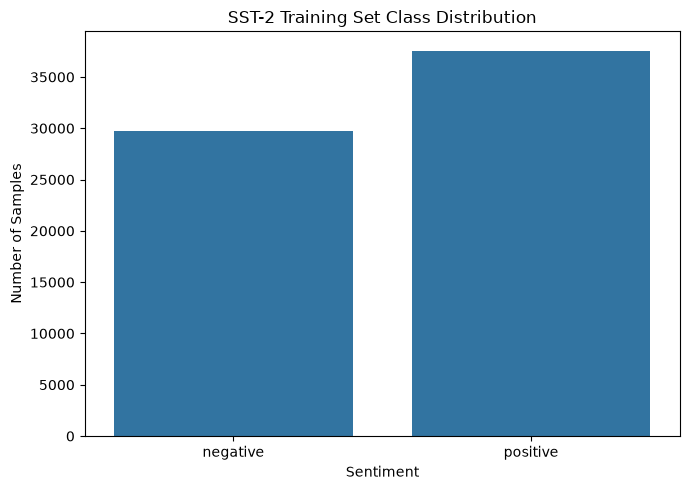

In [6]:
# Calculate class distribution
label_counts = dataset["train"].to_pandas()["label"].value_counts().sort_index()

label_names = dataset["train"].features["label"].names

class_distribution = pd.DataFrame({
    "Sentiment": label_names,
    "Count": label_counts.values,
    "Percentage": (label_counts.values / len(dataset["train"]) * 100).round(2)
})

print(class_distribution)

# Plot class distribution
plt.figure(figsize=(7, 5))

sns.barplot(
    data=class_distribution,
    x="Sentiment",
    y="Count"
)

plt.title("SST-2 Training Set Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

## 5. Sentence Length Analysis

BERT processes text as a sequence of tokens, so the input sequence length must be limited to a fixed maximum value.

We analyze the length of the training sentences to understand the distribution of sentence lengths and select an appropriate maximum sequence length for tokenization.

Sentence Length Statistics:
count    67349.000000
mean         9.409553
std          8.073806
min          1.000000
25%          3.000000
50%          7.000000
75%         13.000000
max         52.000000
Name: sentence_length, dtype: float64


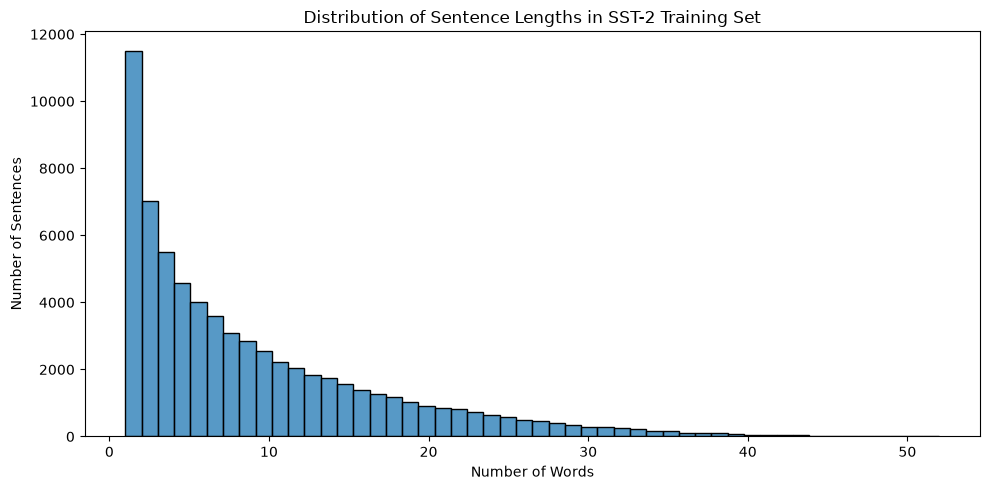

In [7]:
# Calculate sentence lengths in words
train_df = dataset["train"].to_pandas()

train_df["sentence_length"] = train_df["sentence"].str.split().str.len()

# Calculate descriptive statistics
length_stats = train_df["sentence_length"].describe()

print("Sentence Length Statistics:")
print(length_stats)

# Plot sentence length distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["sentence_length"],
    bins=50
)

plt.title("Distribution of Sentence Lengths in SST-2 Training Set")
plt.xlabel("Number of Words")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()

## 6. BERT Tokenizer and Token Length Analysis

BERT does not process raw words directly. It uses a WordPiece tokenizer that converts text into subword tokens and adds special tokens such as `[CLS]` and `[SEP]`.

Before selecting the maximum sequence length, we analyze the tokenized sentence lengths. This allows the sequence length to be chosen based on the actual input representation used by BERT.

BERT Token Length Statistics:
count    67349.000000
mean        13.319262
std          9.545841
min          3.000000
25%          6.000000
50%         10.000000
75%         18.000000
max         66.000000
dtype: float64

Maximum BERT token length: 66


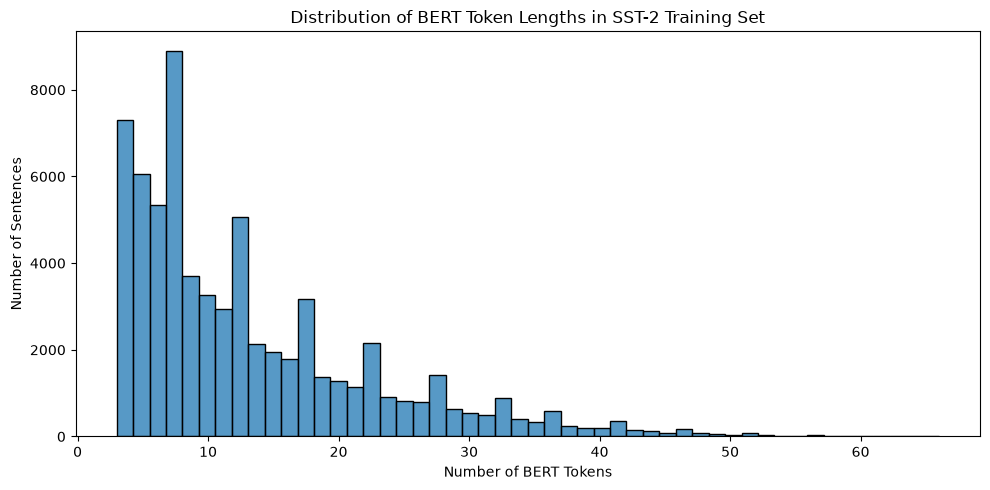

In [8]:
# Load the pre-trained BERT tokenizer
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize training sentences without padding
tokenized_lengths = [
    len(tokenizer.encode(sentence, add_special_tokens=True))
    for sentence in train_df["sentence"]
]

# Calculate BERT token length statistics
token_length_stats = pd.Series(tokenized_lengths).describe()

print("BERT Token Length Statistics:")
print(token_length_stats)

# Display the maximum tokenized length
print(f"\nMaximum BERT token length: {max(tokenized_lengths)}")

# Plot BERT token length distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    tokenized_lengths,
    bins=50
)

plt.title("Distribution of BERT Token Lengths in SST-2 Training Set")
plt.xlabel("Number of BERT Tokens")
plt.ylabel("Number of Sentences")
plt.tight_layout()
plt.show()

## 7. Tokenize the Dataset

The SST-2 sentences are converted into BERT-compatible inputs using the pre-trained `bert-base-uncased` tokenizer.

The tokenizer converts each sentence into:

- `input_ids` — numerical IDs representing the BERT tokens.
- `attention_mask` — identifies real tokens from padding tokens.

A maximum sequence length of 128 tokens is used. Sentences shorter than this length are padded during batching, while longer sentences are truncated.

In [9]:
# Maximum sequence length based on the token length analysis
MAX_LENGTH = 128

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        max_length=MAX_LENGTH
    )

# Tokenize all dataset splits
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

# Display the tokenized dataset structure
print(tokenized_dataset)

# Display one tokenized example
print("\nTokenized example:")
print(tokenized_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

Tokenized example:
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0, 'input_ids': [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


## 8. Prepare Dataset for BERT Training

The tokenized dataset is prepared for training with the Hugging Face `Trainer`.

The original text and index columns are removed because the BERT model only requires the tokenized inputs and sentiment labels during training.

Dynamic padding will be handled using `DataCollatorWithPadding`, which pads each batch only to the length of its longest sequence.

In [10]:
# Remove columns that are not required by the BERT model
columns_to_remove = ["sentence", "idx"]

tokenized_dataset = tokenized_dataset.remove_columns(columns_to_remove)

# Rename label column to labels for compatibility with the Trainer
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Set the dataset format for PyTorch
tokenized_dataset.set_format("torch")

# Dynamic padding for each batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# Display the final dataset structure
print(tokenized_dataset)

# Display one processed example
print("\nProcessed example:")
print(tokenized_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

Processed example:
{'labels': tensor(0), 'input_ids': tensor([  101,  5342,  2047,  3595,  8496,  2013,  1996, 18643,  3197,   102]), 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


## 9. Load the Pre-trained BERT Model

A pre-trained `bert-base-uncased` model is loaded for binary sequence classification.

The model consists of the pre-trained BERT Transformer encoder followed by a classification head. The pre-trained language representations provide a strong starting point for sentiment classification, and the complete model will be fine-tuned on the SST-2 training data.

Since SST-2 contains two sentiment classes, the classification head is configured with two output labels:

- 0 → Negative
- 1 → Positive

In [11]:
# Number of sentiment classes
NUM_LABELS = 2

# Load the pre-trained BERT model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        0: "negative",
        1: "positive"
    },
    label2id={
        "negative": 0,
        "positive": 1
    }
)

# Move the model to the selected device
model = model.to(device)

# Display model information
print(f"Model: {MODEL_NAME}")
print(f"Number of labels: {NUM_LABELS}")
print(f"Device: {device}")
print(f"Total parameters: {model.num_parameters():,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Number of labels: 2
Device: cuda
Total parameters: 109,483,778


## 10. Configure BERT Fine-tuning

The training configuration is defined for fine-tuning the pre-trained BERT model on SST-2.

The model is trained using the AdamW optimizer with a small learning rate suitable for Transformer fine-tuning. Mixed-precision training is enabled to reduce GPU memory usage and improve training efficiency.

Gradient accumulation is used to obtain an effective batch size larger than the physical batch size that can fit comfortably in the available 6 GB GPU memory.

The model is evaluated at the end of every epoch, and the best checkpoint based on validation accuracy is retained.

In [12]:
# Training configuration
OUTPUT_DIR = "./bert-sst2-checkpoint"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,

    # Evaluation
    per_device_eval_batch_size=16,
    eval_strategy="epoch",

    # Optimization
    learning_rate=2e-5,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    warmup_steps=500,

    # Mixed precision for NVIDIA GPU
    fp16=True,

    # Logging
    logging_strategy="steps",
    logging_steps=250,
    report_to="none",

    # Checkpointing
    save_strategy="epoch",
    save_total_limit=1,

    # Select the best model
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # Reproducibility
    seed=SEED,
    data_seed=SEED,

    # Performance
    dataloader_pin_memory=True
)

print("Training configuration:")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size per device: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(
    f"Effective training batch size: "
    f"{training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}"
)
print(f"Learning rate: {training_args.learning_rate}")
print(f"Warmup steps: {training_args.warmup_steps}")
print(f"FP16 enabled: {training_args.fp16}")
print(f"Evaluation strategy: {training_args.eval_strategy}")

Training configuration:
Epochs: 3
Batch size per device: 8
Gradient accumulation: 2
Effective training batch size: 16
Learning rate: 2e-05
Warmup steps: 500
FP16 enabled: True
Evaluation strategy: IntervalStrategy.EPOCH


## 11. Define Evaluation Metrics

The fine-tuned BERT model is evaluated using multiple classification metrics.

The following metrics are calculated on the validation set:

- **Accuracy** — proportion of correctly classified samples.
- **Precision** — proportion of predicted positive samples that are actually positive.
- **Recall** — proportion of actual positive samples correctly identified.
- **F1-score** — harmonic mean of precision and recall.

These metrics provide a more complete evaluation of the binary sentiment classifier than accuracy alone.

In [13]:
# Define evaluation metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Convert model outputs to predicted class labels
    predictions = np.argmax(predictions, axis=1)

    # Calculate metrics
    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


print("Evaluation metrics configured:")
print("Accuracy, Precision, Recall, F1-score")

Evaluation metrics configured:
Accuracy, Precision, Recall, F1-score


## 12. Create the BERT Trainer

The Hugging Face `Trainer` is configured to manage the fine-tuning process.

It combines the pre-trained BERT model, tokenized SST-2 datasets, dynamic padding, training configuration, and evaluation metrics into a single training pipeline.

The validation set is used for evaluation after each training epoch, while the best-performing checkpoint based on validation accuracy is retained.

In [14]:
# Create the Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("BERT Trainer created successfully.")
print(f"Training samples: {len(tokenized_dataset['train']):,}")
print(f"Validation samples: {len(tokenized_dataset['validation']):,}")

BERT Trainer created successfully.
Training samples: 67,349
Validation samples: 872


## 13. Fine-tune the Pre-trained BERT Model

The pre-trained BERT model is fine-tuned on the SST-2 training set for sentiment classification.

During training, the model learns to adapt its pre-trained language representations to distinguish between positive and negative sentiment. The validation set is evaluated after each epoch to monitor the model's performance.

The best-performing model based on validation accuracy is automatically retained for subsequent evaluation.

In [15]:
# Fine-tune BERT on the SST-2 dataset
train_result = trainer.train()

print("\nTraining completed successfully.")
print(f"Training loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.385382,0.294342,0.917431,0.904348,0.936937,0.920354
2,0.288213,0.344018,0.918578,0.915367,0.925676,0.920493
3,0.159426,0.384820,0.925459,0.918322,0.936937,0.927536


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Training completed successfully.
Training loss: 0.3156


## 14. Training Performance Analysis

The training history recorded by the Hugging Face `Trainer` is analyzed to understand the model's learning behavior across epochs.

Training and validation losses are compared to identify convergence and possible overfitting. Validation accuracy and F1-score are also visualized to observe the classification performance during fine-tuning.

In [16]:
# Extract training history
history = pd.DataFrame(trainer.state.log_history)

print("Training history:")
display(history)

# Separate training and evaluation records
train_history = history[
    history["loss"].notna()
][["step", "loss"]].copy()

eval_history = history[
    history["eval_loss"].notna()
][
    ["epoch", "eval_loss", "eval_accuracy", "eval_precision", "eval_recall", "eval_f1"]
].copy()

print("\nEvaluation history:")
display(eval_history)

Training history:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.127771,17.226612,9.960000e-06,0.059389,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.640214,18.737749,1.996000e-05,0.118779,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.579229,25.877264,1.958945e-05,0.178168,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.518284,55.308388,1.917725e-05,0.237558,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.460899,15.068933,1.876505e-05,0.296947,1250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.454854,3.238519,1.835284e-05,0.356337,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.429757,1.182445,1.794064e-05,0.415726,1750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.411307,36.239201,1.752844e-05,0.475116,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.411178,38.576675,1.711624e-05,0.534505,2250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.444403,9.699705,1.670404e-05,0.593895,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Evaluation history:


,epoch,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1
16,1.0,0.294342,0.917431,0.904348,0.936937,0.920354
34,2.0,0.344018,0.918578,0.915367,0.925676,0.920493
52,3.0,0.384820,0.925459,0.918322,0.936937,0.927536


## 15. Training and Validation Performance

The training and validation metrics are visualized to analyze the learning behavior of the fine-tuned BERT model.

The training loss is expected to decrease as the model learns from the training data. Validation loss, accuracy, and F1-score are used to monitor generalization performance across epochs.

A comparison of these metrics helps identify convergence and possible overfitting during fine-tuning.

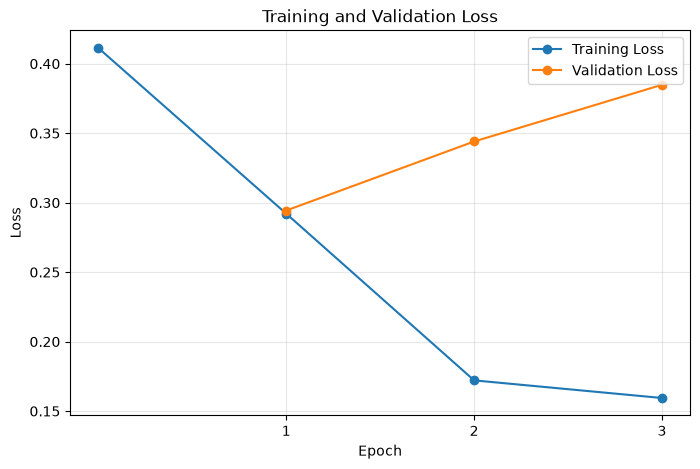

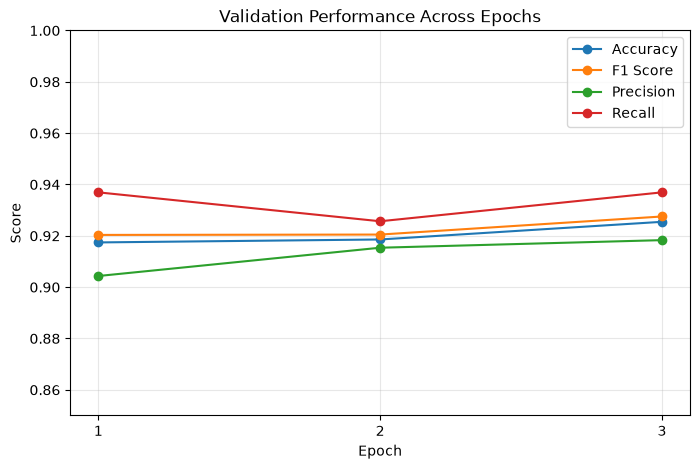

In [17]:
# Prepare epoch-level metrics
epochs = eval_history["epoch"]

train_loss_by_epoch = (
    history[history["loss"].notna()]
    .groupby(history[history["loss"].notna()]["epoch"].round())
    ["loss"]
    .last()
    .reset_index()
)

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(
    train_loss_by_epoch["epoch"],
    train_loss_by_epoch["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    eval_history["epoch"],
    eval_history["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot validation metrics
plt.figure(figsize=(8, 5))
plt.plot(
    eval_history["epoch"],
    eval_history["eval_accuracy"],
    marker="o",
    label="Accuracy"
)
plt.plot(
    eval_history["epoch"],
    eval_history["eval_f1"],
    marker="o",
    label="F1 Score"
)
plt.plot(
    eval_history["epoch"],
    eval_history["eval_precision"],
    marker="o",
    label="Precision"
)
plt.plot(
    eval_history["epoch"],
    eval_history["eval_recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance Across Epochs")
plt.xticks(epochs)
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 16. Final Model Evaluation

The fine-tuned BERT model is evaluated on the complete validation set using accuracy, precision, recall, and F1-score.

Since the SST-2 test split does not provide publicly available sentiment labels for direct evaluation, the validation set is used for the final supervised evaluation.

In [18]:
# Evaluate the fine-tuned BERT model on the validation set
final_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["validation"]
)

print("Final Validation Metrics:")
print(f"Accuracy : {final_metrics['eval_accuracy']:.4f}")
print(f"Precision: {final_metrics['eval_precision']:.4f}")
print(f"Recall   : {final_metrics['eval_recall']:.4f}")
print(f"F1 Score : {final_metrics['eval_f1']:.4f}")
print(f"Loss     : {final_metrics['eval_loss']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.159426,0.384820,3,0.925459,0.918322,0.936937,0.927536


Final Validation Metrics:
Accuracy : 0.9255
Precision: 0.9183
Recall   : 0.9369
F1 Score : 0.9275
Loss     : 0.3848


## 17. Confusion Matrix

A confusion matrix is used to examine the classification behavior of the fine-tuned BERT model.

It shows the number of correctly and incorrectly classified negative and positive sentiment samples, allowing us to identify which class is more frequently misclassified.

Confusion Matrix:
[[391  37]
 [ 28 416]]


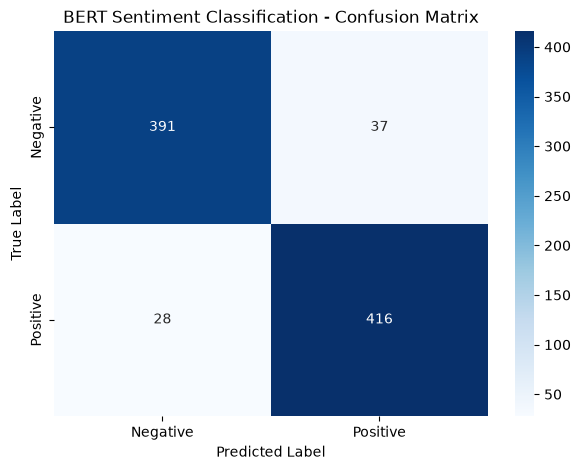

In [19]:
# Generate predictions on the validation set
predictions = trainer.predict(tokenized_dataset["validation"])

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Sentiment Classification - Confusion Matrix")
plt.show()

## 18. Classification Report

The classification report provides class-wise precision, recall, and F1-score for the negative and positive sentiment classes.

This provides a more detailed evaluation of the BERT model beyond overall accuracy.

In [20]:
# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    digits=4
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9332    0.9136    0.9233       428
    Positive     0.9183    0.9369    0.9275       444

    accuracy                         0.9255       872
   macro avg     0.9257    0.9252    0.9254       872
weighted avg     0.9256    0.9255    0.9254       872



## 19. Sample Sentiment Predictions

The fine-tuned BERT model is tested on a small set of custom sentences to demonstrate its ability to classify previously unseen text.

The predicted sentiment and confidence score are displayed for each sample.

In [21]:
# Sample sentences for inference
sample_sentences = [
    "This movie was absolutely wonderful and I loved every minute of it.",
    "The film was boring, predictable, and disappointing.",
    "An enjoyable story with excellent performances.",
    "I would not recommend this movie to anyone."
]

# Tokenize sample sentences
sample_inputs = tokenizer(
    sample_sentences,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

# Move inputs to the same device as the model
sample_inputs = {
    key: value.to(device)
    for key, value in sample_inputs.items()
}

# Generate predictions
model.eval()

with torch.no_grad():
    outputs = model(**sample_inputs)
    probabilities = torch.softmax(outputs.logits, dim=-1)
    predicted_labels = torch.argmax(probabilities, dim=-1)

# Display predictions
for sentence, label, probs in zip(
    sample_sentences,
    predicted_labels.cpu().numpy(),
    probabilities.cpu().numpy()
):
    sentiment = "Positive" if label == 1 else "Negative"
    confidence = probs[label] * 100

    print(f"Sentence   : {sentence}")
    print(f"Prediction : {sentiment}")
    print(f"Confidence : {confidence:.2f}%")
    print("-" * 80)

Sentence   : This movie was absolutely wonderful and I loved every minute of it.
Prediction : Positive
Confidence : 99.99%
--------------------------------------------------------------------------------
Sentence   : The film was boring, predictable, and disappointing.
Prediction : Negative
Confidence : 99.98%
--------------------------------------------------------------------------------
Sentence   : An enjoyable story with excellent performances.
Prediction : Positive
Confidence : 99.99%
--------------------------------------------------------------------------------
Sentence   : I would not recommend this movie to anyone.
Prediction : Negative
Confidence : 99.89%
--------------------------------------------------------------------------------


## 20. Final Results and Model Analysis

The fine-tuned BERT model achieved strong sentiment classification performance on the SST-2 validation set.

The final evaluation results are summarized below:

| Metric | Score |
|---|---:|
| Accuracy | 92.55% |
| Precision | 91.83% |
| Recall | 93.69% |
| F1 Score | 92.75% |
| Validation Loss | 0.3848 |

The confusion matrix shows that 391 negative and 416 positive reviews were classified correctly, while 37 negative reviews were classified as positive and 28 positive reviews were classified as negative.

The classification report shows relatively balanced performance between the two sentiment classes. The positive class achieved a recall of 93.69%, while the negative class achieved a precision of 93.32%.

During training, the training loss decreased consistently. However, the validation loss increased after the first epoch, indicating some degree of overfitting. Despite this, validation accuracy and F1-score continued to improve, reaching their highest recorded values at epoch 3.

The custom inference examples were also classified correctly, demonstrating that the fine-tuned BERT model can generalize to new sentiment-bearing sentences.

In [22]:
# Create a concise final results table
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Validation Loss"
    ],
    "Score": [
        final_metrics["eval_accuracy"],
        final_metrics["eval_precision"],
        final_metrics["eval_recall"],
        final_metrics["eval_f1"],
        final_metrics["eval_loss"]
    ]
})

final_results

,Metric,Score
0,Accuracy,0.925459
1,Precision,0.918322
2,Recall,0.936937
3,F1 Score,0.927536
4,Validation Loss,0.384820


## 21. Conclusion

In this assignment, a pre-trained BERT model (`bert-base-uncased`) was fine-tuned for binary sentiment classification using the SST-2 dataset.

The dataset was explored through class distribution and sentence/token length analysis, followed by BERT tokenization and preparation for model training. The pre-trained BERT model was then fine-tuned using the Hugging Face `Trainer` framework.

The model achieved the following results on the validation set:

- **Accuracy:** 92.55%
- **Precision:** 91.83%
- **Recall:** 93.69%
- **F1 Score:** 92.75%

The confusion matrix and classification report showed balanced performance across negative and positive sentiment classes. The model also successfully classified custom unseen sentences during inference.